## Task 1 : Data Collection & Dataset Understanding
### Goal:
- Collect or load a dataset and understand its structure.
Key Requirements:
- Identify columns and data types
- Understand dataset size and features
- Describe what the data represents
### Key Skills:
- Data understanding, exploratory thinking

In [1]:
import pandas as pd 
import numpy as np
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
data = pd.read_csv('diabetes.csv')

In [3]:
data.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB


In [5]:
data.dtypes

id            int64
chol        float64
stab.glu      int64
hdl         float64
ratio       float64
glyhb       float64
location     object
age           int64
gender       object
height      float64
weight      float64
frame        object
bp.1s       float64
bp.1d       float64
bp.2s       float64
bp.2d       float64
waist       float64
hip         float64
time.ppn    float64
dtype: object

In [6]:
data.size

7657

In [7]:
data.shape

(403, 19)

## The data represents
1. Biochemical markers:
```chol``` : Total cholesterol,
```stab.glu``` : Stabilized glucose (fasting blood sugar),
```hdl``` : High-density lipoprotein cholesterol (the “good” cholesterol),
```ratio``` : Cholesterol-to-HDL ratio,
```glyhb``` : Glycated hemoglobin (HbA1c), a key marker of long-term blood sugar control.
2. Demographics:
```location``` : Where the patient is from,
```age``` : Age in years,
```gender``` : Male or female,
```frame``` : Body frame size (small, medium, large).
3. Anthropometrics:
```height``` : Height in inches,
```weight``` : Weight in pounds,
```waist and hip``` : Circumference measurements, useful for waist-to-hip ratio
4. Blood pressure:
```bp.1s```, ```bp.1d``` : First systolic and diastolic blood pressure readings,
```bp.2s```, ```bp.2d``` : Second readings (if available).
5. Other clinical info:
```time.ppn``` : Time postprandial (after eating), which can affect glucose levels

## Task 2: Data Cleaning & Preprocessing
### Goal:
- Prepare the dataset for analysis by cleaning and organizing data.
### Key Requirements:
- Handle missing values.
- Remove duplicates.
- Format data correctly.
### Key Skills:
- Data preprocessing, data quality management.

In [8]:
# Missing values per column
data.isnull().sum()

id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64

In [9]:
data.duplicated().sum()

0

In [10]:
# filling numerical missing values with mean
numerical_cols = data.select_dtypes(include=[np.number]).columns
categorical_cols = data.select_dtypes(include=['object']).columns
for col in numerical_cols:
    data[col].fillna(data[col].mean(), inplace=True)
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [11]:
data.isnull().sum().sum()

0

In [12]:
# Ensure correct data types
data['gender'] = data['gender'].astype('category')
data['location'] = data['location'].astype('category')

## Task 3: Exploratory Data Analysis (EDA)
### Goal:
- Analyze the dataset to discover patterns and trends.
### Key Requirements:
- Calculate basic statistics.
- Identify trends and outliers.
- Summarize findings.
### Key Skills:
- Statistical thinking, data analysis.

In [13]:
# Basic statistics
data.describe()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.00000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.59204,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.390242,53.076655,17.241141,1.725736,2.206036,16.312333,3.894070,40.29046,22.599166,13.504452,12.813562,6.819121,5.715043,5.642624,308.383786
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.00000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.390000,34.000000,63.000000,151.00000,122.000000,75.000000,152.382979,92.524823,33.000000,39.000000,97.500000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.870000,45.000000,66.000000,173.00000,136.000000,82.000000,152.382979,92.524823,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.589769,60.000000,69.000000,200.00000,146.000000,90.000000,152.382979,92.524823,41.000000,46.000000,495.000000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.00000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


In [14]:
corr = data[numerical_cols].corr()
print("Correlation with glyhb:\n", corr['glyhb'].sort_values(ascending=False))

Correlation with glyhb:
 glyhb       1.000000
stab.glu    0.747041
age         0.335930
ratio       0.325137
chol        0.244407
waist       0.223218
bp.1s       0.196383
weight      0.166749
hip         0.138550
height      0.061628
time.ppn    0.031812
bp.1d       0.031711
bp.2s       0.029610
id          0.010164
bp.2d      -0.103085
hdl        -0.146987
Name: glyhb, dtype: float64


In [15]:
# Identify outliers 
z_scores = np.abs(zscore(data[numerical_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("Outliers per column:\n", outliers)

Outliers per column:
 id           0
chol         4
stab.glu    13
hdl          6
ratio        3
glyhb       11
age          0
height       1
weight       3
bp.1s        5
bp.1d        1
bp.2s        8
bp.2d       10
waist        1
hip          4
time.ppn     5
dtype: int64


In [16]:
# remove outliers
#data = data[(z_scores < 3).all(axis=1)]

In [17]:
data.shape

(403, 19)

In [18]:
# group trends by gender
trend_gender = data.groupby('gender')['glyhb'].mean()
print("Average glyhb by gender:")
print(trend_gender)

Average glyhb by gender:
gender
female    5.496789
male      5.718511
Name: glyhb, dtype: float64


In [19]:
# Age trend
trend_age = data.groupby('age')['glyhb'].mean().head(10)
print("Average glyhb by age (first 10 ages):")
print(trend_age)

Average glyhb by age (first 10 ages):
age
19    4.535000
20    4.600000
21    4.378333
22    4.046000
23    4.634286
24    4.610000
25    4.895000
26    5.398333
27    4.555556
28    4.441085
Name: glyhb, dtype: float64


## Task 4: Data Visualization 
### Goal:
- Create visual representations to communicate insights clearly.
### Key Requirements:
- Create charts and graphs.
- Choose appropriate visual types.
- Highlight key insights.
### Key Skills:
- Data visualization, storytelling with data

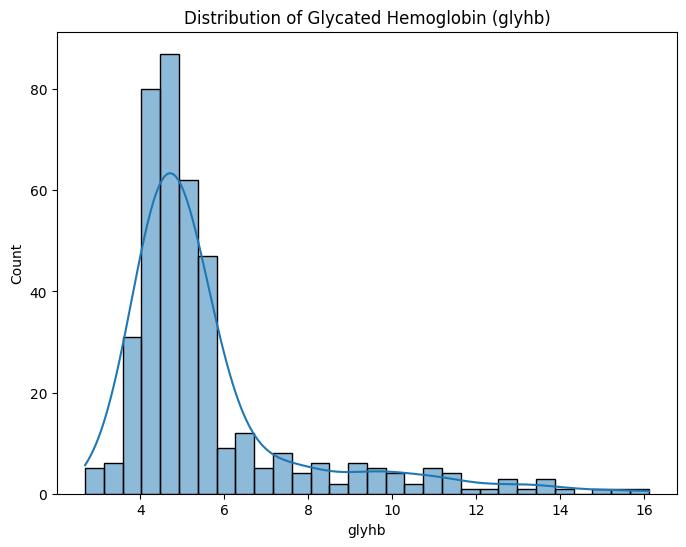

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(data['glyhb'], bins=30, kde=True)
plt.title("Distribution of Glycated Hemoglobin (glyhb)")
plt.show()

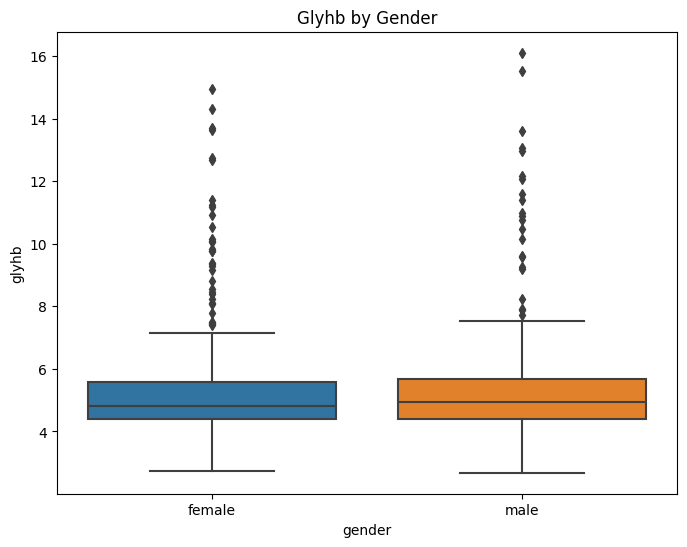

In [21]:
plt.figure(figsize=(8,6))
sns.boxplot(x='gender', y='glyhb', data=data)
plt.title("Glyhb by Gender")
plt.show()

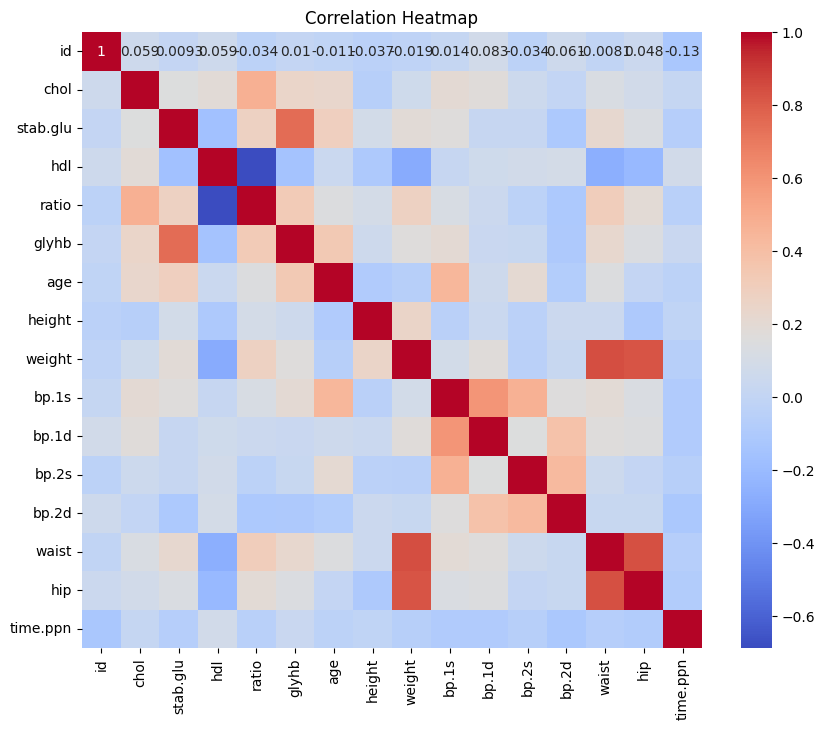

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

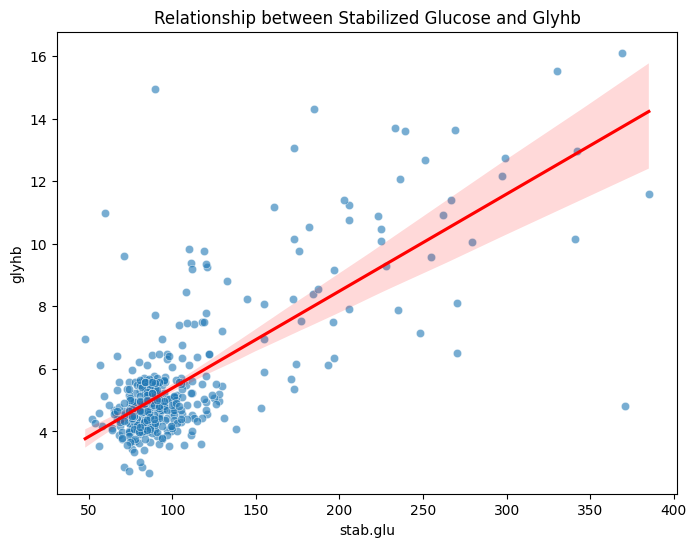

In [23]:
#  Glyhb vs Stabilized Glucose
plt.figure(figsize=(8,6))
sns.scatterplot(x='stab.glu', y='glyhb', data=data, alpha=0.6)
sns.regplot(x='stab.glu', y='glyhb', data=data, scatter=False, color='red')
plt.title("Relationship between Stabilized Glucose and Glyhb")
plt.show()

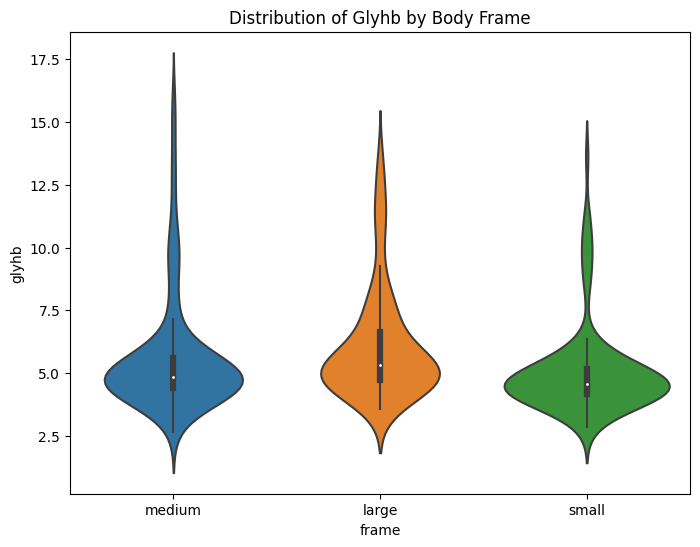

In [24]:
# Glyhb by Frame Size
plt.figure(figsize=(8,6))
sns.violinplot(x='frame', y='glyhb', data=data)
plt.title("Distribution of Glyhb by Body Frame")
plt.show()

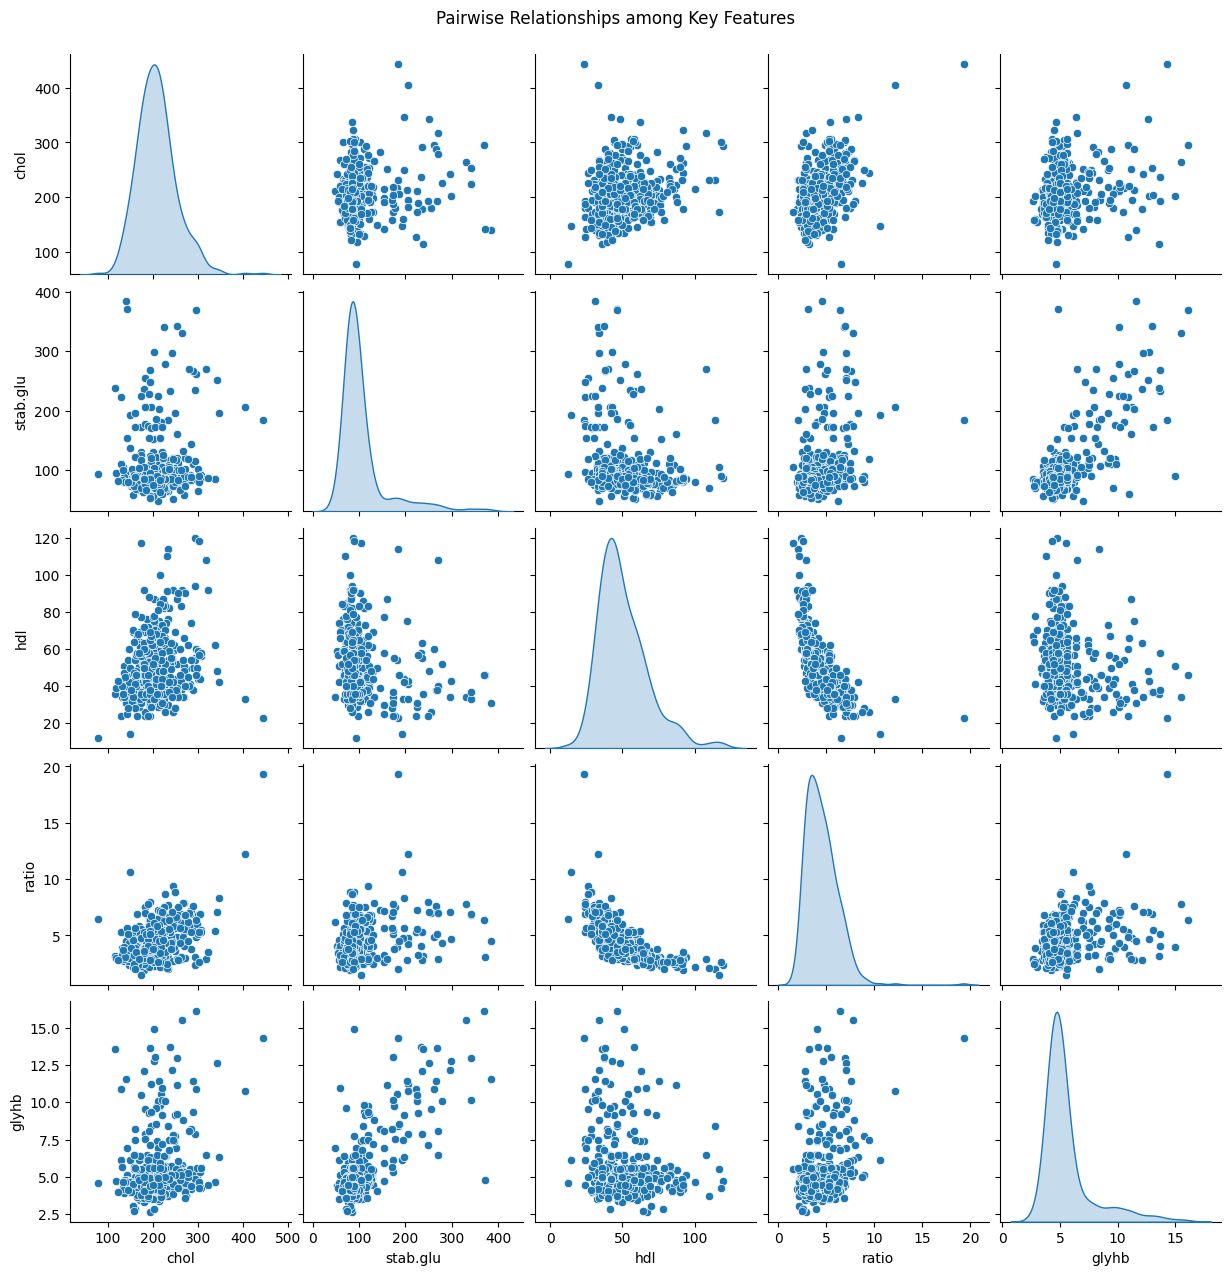

In [25]:
# Selected Features
selected_features = ['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb']
sns.pairplot(data[selected_features], diag_kind='kde')
plt.suptitle("Pairwise Relationships among Key Features", y=1.02)
plt.show()

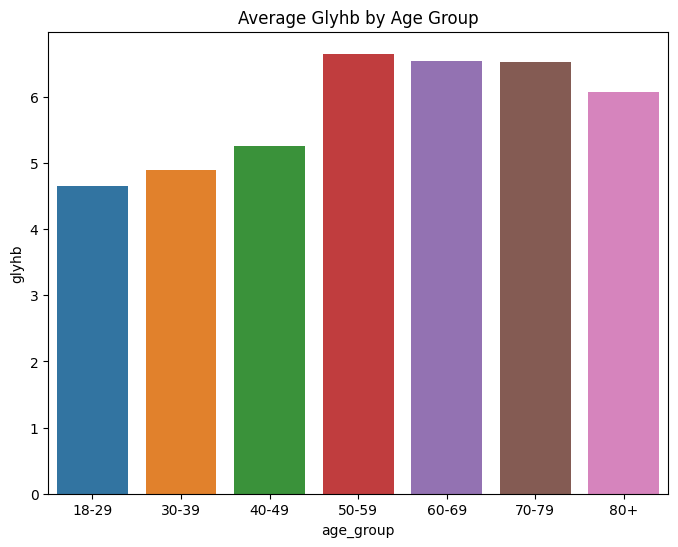

In [26]:
# Average Glyhb by Age Group
data['age_group'] = pd.cut(data['age'], bins=[18,30,40,50,60,70,80,100],
                         labels=['18-29','30-39','40-49','50-59','60-69','70-79','80+'])
plt.figure(figsize=(8,6))
sns.barplot(x='age_group', y='glyhb', data=data,errorbar=None)
plt.title("Average Glyhb by Age Group")
plt.show()

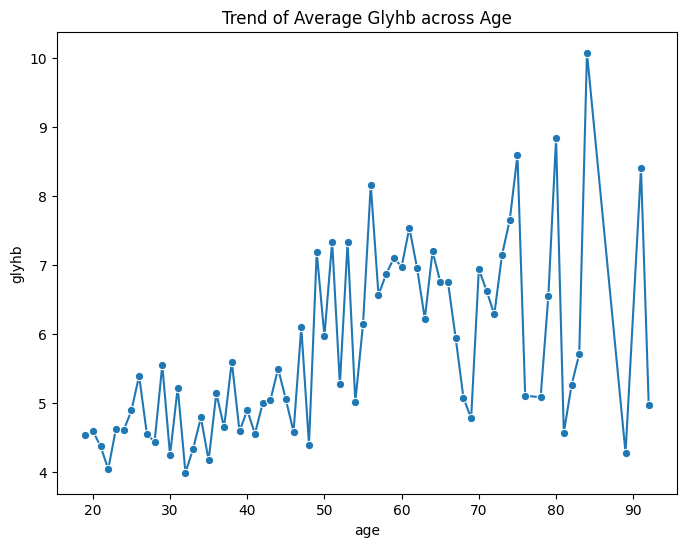

In [27]:
# Average Glyhb over Age
age_trend = data.groupby('age')['glyhb'].mean().reset_index()
plt.figure(figsize=(8,6))
sns.lineplot(x='age', y='glyhb', data=age_trend, marker='o')
plt.title("Trend of Average Glyhb across Age")
plt.show()

## Task 5: Predictive Model or Insight Project 
### Goal:
- Build a simple predictive model or generate meaningful insights from data.
### Examples:
- Simple prediction using regression.
- Classification of data.
- Insight-based recommendation.
### Key Skills:
- Basic machine learning concepts, model understanding.

In [28]:
features = ['chol', 'stab.glu', 'hdl', 'ratio', 'age', 'weight', 'bp.1s', 'bp.1d']
X = data[features]
y = data['glyhb']

# data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
# Models
model1 = LinearRegression()
model1.fit(X_train, y_train)
# Predictions
y_pred = model1.predict(X_test)

print("Model coefficients:\n", dict(zip(features, model1.coef_)))
print("Intercept:", model1.intercept_)
print("R² score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Model coefficients:
 {'chol': 0.00013491628210497838, 'stab.glu': 0.027851514524854463, 'hdl': 0.006714738597696347, 'ratio': 0.22533608001830802, 'age': 0.01590637028183841, 'weight': 0.0002641018267354414, 'bp.1s': 0.0007600833979319804, 'bp.1d': -0.0010783552262316422}
Intercept: 0.4793724921513567
R² score: 0.7664318835627874
RMSE: 1.0629961472834257


In [30]:
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("Random Forest R² score:", r2_score(y_test, y_pred2))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))

Random Forest R² score: 0.5913416920593066
Random Forest RMSE: 1.4060639627502005
